# 2D PD model

critical_stretch:  0.0004618802153517005


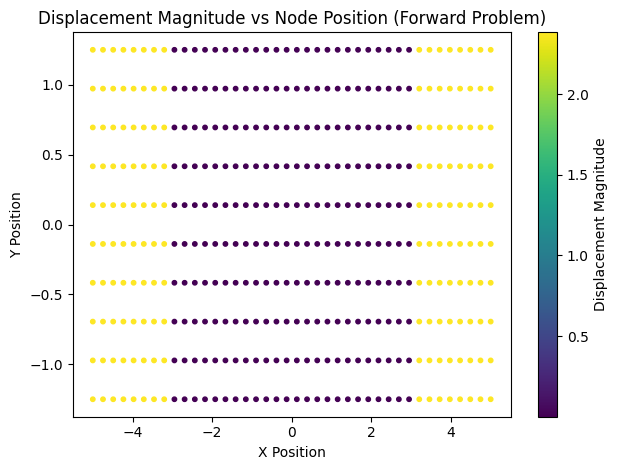

In [ ]:
from functools import partial
import time

import jax
import jax.numpy as jnp

import numpy as np
import scipy.spatial
import scipy.optimize
import matplotlib.pyplot as plt
import matplotlib.animation as animation



import jax.scipy
import jax.scipy.optimize
from jax.scipy.optimize import minimize
from jax.nn import softplus

from jax import grad, jit


from typing import Union, Tuple

import optax
from jax import jit, vmap, grad, value_and_grad
from jax import lax
from jax import grad
from jax.experimental import checkify


import jax
import jax.numpy as jnp
import numpy as np
import scipy.spatial
from typing import Union, NamedTuple, Optional


# ----------------------------
# PARAMETER STRUCT
# ----------------------------
class PDParams(NamedTuple):
	bar_length: float
	number_of_elements: int
	bulk_modulus: float
	density: float
	thickness: jnp.ndarray
	horizon: float
	critical_stretch: Optional[float]
	prescribed_velocity: Optional[float]
	prescribed_force: Optional[float]
	nodes: jnp.ndarray
	lengths: jnp.ndarray
	pd_nodes: jnp.ndarray
	num_nodes: int
	neighborhood: jnp.ndarray
	reference_position_state: jnp.ndarray
	reference_magnitude_state: jnp.ndarray
	num_neighbors: jnp.ndarray
	max_neighbors: int
	no_damage_region_left: jnp.ndarray
	no_damage_region_right: jnp.ndarray
	width: float  
	right_bc_region: jnp.ndarray
	left_bc_region: jnp.ndarray
	undamaged_influence_state_left: jnp.ndarray
	undamaged_influence_state_right: jnp.ndarray
	dx: float
	dy: float 


class PDState(NamedTuple):
	disp_x: jnp.ndarray
	disp_y: jnp.ndarray
	vel_x: jnp.ndarray
	vel_y: jnp.ndarray
	acc_x: jnp.ndarray
	acc_y: jnp.ndarray
	vol_state: jnp.ndarray
	rev_vol_state: jnp.ndarray
	influence_state: jnp.ndarray
	undamaged_influence_state: jnp.ndarray
	loss_damage: jnp.ndarray
	damage: jnp.ndarray
	forces_array: jnp.ndarray
	disp_array: jnp.ndarray
	velo_array: jnp.ndarray
	strain_energy: jnp.ndarray
	time: float


# ----------------------------
# GLOBAL INITIALIZATION FUNCTION
# ----------------------------
def init_problem(bar_length: float = 20.0,
				 density: float = 1.0,
				 bulk_modulus: float = 100.0,
				 number_of_elements: int = 20,
				 horizon: Optional[float] = None,
				 thickness: Union[float, np.ndarray] = 1.0,
     			 density_field: Union[float, np.ndarray] = 1.0,
				 prescribed_velocity: Optional[float] = None,
				 prescribed_force: Optional[float] = None,
				 critical_stretch: Optional[float]= None):

	
	"""
	Create PDParams and PDState tuples for a new problem.
	"""

	delta_x = bar_length / number_of_elements
	if horizon is None:
		horizon = delta_x * 3.015
	
	# nodes and element lengths
	nodes = jnp.linspace(-bar_length / 2.0, bar_length / 2.0, num=number_of_elements + 1)
	#lengths = jnp.array(nodes[1:] - nodes[0:-1])


	nx, ny = number_of_elements, number_of_elements // 4  # number of nodes in x and y
	dx, dy = bar_length / nx, bar_length / ny
	x = jnp.linspace(-bar_length/2, bar_length/2, nx)
	y = jnp.linspace(-bar_length/8, bar_length/8, ny)
	X, Y = jnp.meshgrid(x, y)
	pd_nodes = jnp.stack([X.flatten(), Y.flatten()], axis=1)  # shape (num_nodes, 2)
	num_nodes = pd_nodes.shape[0]

	lengths = jnp.full(num_nodes, dx)  # Changed from 1D element lengths

 	# thickness as array
	if jnp.ndim(thickness) == 0:  # scalar
		thickness_arr = jnp.full((num_nodes,), thickness)
	elif isinstance(thickness, (np.ndarray, jnp.ndarray)):
		assert thickness.shape[0] == num_nodes, "Thickness array length must match number of nodes."
		thickness_arr = jnp.asarray(thickness)
	else:
		raise ValueError("Invalid thickness input.")


	# density as array
	if jnp.ndim(density_field) == 0:  # scalar
		density_field = jnp.full((num_nodes,), density_field)
	elif isinstance(density_field, (np.ndarray, jnp.ndarray)):
		assert density_field.shape[0] == num_nodes, "Density array length must match number of nodes."
		density_field = jnp.asarray(density_field)
	else:
		raise ValueError("Invalid density input.")


	# kdtree setup
	tree = scipy.spatial.cKDTree(pd_nodes)
	reference_magnitude_state, neighborhood = tree.query(
		pd_nodes, k=100, p=2, eps=0.0,
		distance_upper_bound=(horizon + np.max(lengths) / 2.0))
 
	reference_position_state = pd_nodes[neighborhood] - pd_nodes[:, None, :]  # (num_nodes, max_neighbors, 2)
	reference_magnitude_state = jnp.linalg.norm(reference_position_state, axis=-1)

	# trim out self-distance column
	reference_magnitude_state = jnp.delete(reference_magnitude_state, 0, 1)

	num_neighbors = jnp.asarray((neighborhood != tree.n).sum(axis=1)) - 1
	max_neighbors = int(np.max((neighborhood != tree.n).sum(axis=1)))

	neighborhood = jnp.asarray(neighborhood[:, :max_neighbors])
	reference_magnitude_state = reference_magnitude_state[0:, :max_neighbors - 1]

	row_indices = jnp.arange(neighborhood.shape[0]).reshape(-1, 1)
	neighborhood = jnp.where(neighborhood == tree.n, row_indices, neighborhood)
	neighborhood = jnp.delete(neighborhood, 0, 1)

	reference_position_state = pd_nodes[neighborhood] - pd_nodes[:, None]
	reference_magnitude_state = jnp.linalg.norm(reference_position_state, axis=-1)  # Update to match trimmed positions
	reference_magnitude_state = jnp.where(reference_magnitude_state == np.inf, 0.0, reference_magnitude_state)
	#jax.debug.print("reference_magnitude_state = {r}", r=reference_magnitude_state)

	if prescribed_velocity is not None and prescribed_force is not None:
		raise ValueError("Only one of prescribed_velocity or prescribed_force should be set, not both.")
	
	if prescribed_velocity is None and prescribed_force is None:
		raise ValueError("Either prescribed_velocity or prescribed_force must be set.")

	#:The node indices of the boundary region at the left end of the bar
	li = 0
	#left_bc_mask = neighborhood[li] != li
	#left_bc_region = neighborhood[li][left_bc_mask]

	#:The node indices of the boundary region at the right end of the bar
	ri = num_nodes - 1
	#right_bc_mask = neighborhood[ri] != ri
	#right_bc_region = neighborhood[ri][right_bc_mask]


	# Define the y-range for the left side selection (adjust ymin and ymax as needed)
	ymin = -bar_length/2.0   # Example: start of y-range (e.g., bottom quarter)
	ymax = bar_length/2.0    # Example: end of y-range (e.g., top quarter)

	# Select nodes on the leftmost boundary (x == min_x) within the y-range [ymin:ymax]
	# Get unique x-values and sort them
	unique_x = jnp.unique(pd_nodes[:, 0])
	sorted_x = jnp.sort(unique_x)

	# Select the three leftmost x-values
	leftmost_x = sorted_x[:3]

	tol = 1e-8

	# Create mask for nodes with x in the leftmost three rows
	#left_edge_mask = jnp.isin(pd_nodes[:, 0], leftmost_x)
	left_edge_mask = (pd_nodes[:, 0] <= sorted_x[2] + tol)
	left_bc_region = jnp.where(left_edge_mask)[0]  # Indices of selected nodes

	# Select nodes on the leftmost boundary (x == min_x) within the y-range [ymin:ymax]
	# Get unique x-values and sort them
	unique_x = jnp.unique(pd_nodes[:, 0])
	sorted_x = jnp.sort(unique_x)

	# Select the three rightmost x-values
	rightmost_x = sorted_x[-3:]

	# Create mask for nodes with x in the rightmost three rows
	right_edge_mask = (pd_nodes[:, 0] >= sorted_x[-3] - tol)
	#right_edge_mask = jnp.isin(pd_nodes[:, 0], rightmost_x)
	right_bc_region = jnp.where(right_edge_mask)[0]  # Indices of selected nodes
	## from 1D
	#right_bc_region = jnp.asarray(tree.query_ball_point(pd_nodes[-1, None], r=(2.0 * horizon ), p=2, eps=0.0)).sort()

	if prescribed_velocity is not None:
		left_bc_region = jnp.asarray(tree.query_ball_point(pd_nodes[0], r=(horizon + np.max(lengths) / 2.0), p=2, eps=0.0)).sort()
		right_bc_region = jnp.asarray(tree.query_ball_point(pd_nodes[-1], r=(horizon + np.max(lengths) / 2.0), p=2, eps=0.0)).sort()

	## setting no damage regions using all selected nodes along an edge ##
	# Get unique x-values and sort them
	unique_x = jnp.unique(pd_nodes[:, 0])
	sorted_x = jnp.sort(unique_x)

	# Select the five leftmost x-values
	leftmost_x = sorted_x[:5]

	
	# Create mask for nodes with x in the leftmost five rows
	no_damage_left_mask = jnp.isin(pd_nodes[:, 0], leftmost_x)
	no_damage_region_left = jnp.where(no_damage_left_mask)[0]  # Indices of selected nodes
 
	# Select the three rightmost x-values
	rightmost_x = sorted_x[-5:]
	# Create mask for nodes with x in the rightmost three rows
	no_damage_right_mask = jnp.isin(pd_nodes[:, 0], rightmost_x)
	no_damage_region_right = jnp.where(no_damage_right_mask)[0]  # Indices of selected nodes
	


	# initial vol_state (full volume)
	vol_state = jnp.ones((num_nodes, max_neighbors - 1))
	rev_vol_state = vol_state.copy()

	#jax.debug.print("vol_state in init: {v}",v=vol_state)

	influence_state = jnp.where(vol_state > 1.0e-16, 1.0, 0.0)
	undamaged_influence_state = influence_state.copy()

	# Define the node indices for the 4x4 middle chunk
	'''
	#node_indices = jnp.array([139, 140, 141, 142, 179, 180, 181, 182, 219, 220, 221, 222, 259, 260, 261, 262])
	#node_indices = jnp.array([259, 260, 261, 262, 299, 300, 301, 302, 339, 340, 341, 342, 379, 380, 381, 382])
	node_indices = jnp.array([
    139, 140, 141, 142,  # Row 3, cols 19-22
    179, 180, 181, 182,  # Row 4, cols 19-22
    219, 220, 221, 222,  # Row 5, cols 19-22
    259, 260, 261, 262,  # Row 6, cols 19-22
    299, 300, 301, 302,  # Row 7, cols 19-22
    339, 340, 341, 342,  # Row 8, cols 19-22
    379, 380, 381, 382])   # Row 9, cols 19-22 (top row)
	'''

	# Set influence state to 0 for all neighbors of these nodes
	#influence_state = influence_state.at[node_indices, :].set(0.0)
	#influence_state = influence_state.at[18:23,19:24].set(0.0)
	
	undamaged_influence_state_left = influence_state.at[no_damage_region_left, :].get()
	undamaged_influence_state_right = influence_state.at[no_damage_region_right, :].get()

	width = 1.0  # Width of the bar, can be adjusted if needed


	# package params
	params = PDParams(
		bar_length, number_of_elements, bulk_modulus, density, thickness_arr,
		horizon, critical_stretch, prescribed_velocity, prescribed_force,
		nodes, lengths, pd_nodes, num_nodes, neighborhood,
		reference_position_state, reference_magnitude_state, num_neighbors, max_neighbors,
		no_damage_region_left, no_damage_region_right, width, right_bc_region, left_bc_region,
		undamaged_influence_state_left, undamaged_influence_state_right, dx, dy
	)


	# package initial state
	state = PDState(
		disp_x=jnp.zeros((num_nodes, 2)),
		disp_y=jnp.zeros((num_nodes, 2)),
		vel_x=jnp.zeros((num_nodes, 2)),
		vel_y=jnp.zeros((num_nodes, 2)),
		acc_x=jnp.zeros((num_nodes, 2)),
		acc_y=jnp.zeros((num_nodes, 2)),
		vol_state=vol_state,
		rev_vol_state=rev_vol_state,
		influence_state=influence_state,
		undamaged_influence_state=undamaged_influence_state,
		forces_array=jnp.zeros((num_nodes, 2)),
		disp_array=jnp.zeros((num_nodes, 2)),
		velo_array=jnp.zeros((num_nodes, 2)),
		strain_energy=0.0,
		damage=jnp.zeros(num_nodes),
		loss_damage=jnp.zeros(num_nodes),
		time=0.0
	)

	return params, state


############### global functions to replace jnp.where functions in compute_partial_volumes ###############
@jax.jit
def vol_state_uncorrected_where(ref_mag_state: jax.Array, vol_state_uncorrected: jax.Array):
	"""
	Replace entries in vol_state_uncorrected with 0.0 where ref_mag_state < 1.0e-16,
	using lax.cond and nested vmap for full JIT/grad compatibility.
	Works for 1D or 2D arrays.
	"""
	# Scalar conditional
	def cond_fn(r, v):
		return jax.lax.cond(r < 1e-16, lambda _: 0.0, lambda _: v, operand=None)

	# Vectorize over columns (neighbors)
	col_fn = jax.vmap(cond_fn, in_axes=(0, 0))
	# Vectorize over rows (nodes)
	return jax.vmap(col_fn, in_axes=(0, 0))(ref_mag_state, vol_state_uncorrected)


@jax.jit
def vol_state_where(ref_mag_state: jax.Array, horiz: float, lens: jax.Array, neigh: jax.Array, vol_state_uncorrected: jax.Array):
	"""
	Replace entries in vol_state_uncorrected with 0.0 where
	ref_mag_state >= horiz + lens[neigh] / 2.0,
	using lax.cond and nested vmap.
	Works for 1D or 2D arrays.
	"""
	threshold = horiz + lens[neigh] / 2.0  # shape matches ref_mag_state

	# Scalar conditional
	def cond_fn(r, thresh, v):
		return jax.lax.cond(r < thresh, lambda _: v, lambda _: 0.0, operand=None)

	# Vectorize over columns (neighbors)
	col_fn = jax.vmap(cond_fn, in_axes=(0, 0, 0))
	# Vectorize over rows (nodes)
	return jax.vmap(col_fn, in_axes=(0, 0, 0))(ref_mag_state, threshold, vol_state_uncorrected)


def vol_state_clip_where(vol_state: jax.Array, vol_state_uncorrected: jax.Array):
    return jnp.minimum(vol_state, vol_state_uncorrected)

######################################################################################
def compute_partial_volumes(params, thickness:jax.Array, density_field:jax.Array):

	# Setup some local (to function) convenience variables
	neigh = params.neighborhood
	lens = params.lengths  # Now (num_nodes,)
	ref_mag_state = params.reference_magnitude_state
	horiz = params.horizon
	dx = params.dx
	dy = params.dy

	    # Handle scalar density_field (expand to array if needed)
	if jnp.ndim(density_field) == 0:  # scalar
		density_field = jnp.full((params.num_nodes,), density_field)
	elif isinstance(density_field, (np.ndarray, jnp.ndarray)):
		assert density_field.shape[0] == params.num_nodes, "Density array length must match number of nodes."
		density_field = jnp.asarray(density_field)
	else:
		raise ValueError("Invalid density_field input.")
    

	# Initialize the volume_state to the lengths * width * thickness

	vol_state_uncorrected = dx * dy * thickness[neigh]  # Now dx * dy * thickness per bond

	#Zero out entries that are not in the family
	#vol_state_uncorrected = jnp.where(ref_mag_state < 1.0e-16, 0.0, vol_state_uncorrected) 
	vol_state_uncorrected = vol_state_uncorrected_where(ref_mag_state, vol_state_uncorrected)


	#vol_state = jnp.where(ref_mag_state < horiz + lens[neigh] / 2.0, vol_state_uncorrected, 0.0)
	vol_state = vol_state_where(ref_mag_state, horiz, lens, neigh, vol_state_uncorrected)  

	###### 1D partial volume calculations, no transferable in 2D ######
	# Check to see if the neighboring node has a partial volume
	#is_partial_volume = jnp.abs(horiz - ref_mag_state) < lens[neigh] / 2.0
	#jax.debug.print("Any NaNs? {y}", y=jnp.any(jnp.isnan(is_partial_volume)))

	# Two different scenarios:
	#is_partial_volume_case1 = is_partial_volume * (ref_mag_state >= horiz)
	#is_partial_volume_case2 = is_partial_volume * (ref_mag_state < horiz)

	# Compute the partial volumes conditionally
	#vol_state = jnp.where(is_partial_volume_case1, (lens[neigh] / 2.0 - (ref_mag_state - horiz)) * dy * thickness[neigh], vol_state)
	#vol_state = jnp.where(is_partial_volume_case2, (lens[neigh] / 2.0 + (horiz - ref_mag_state)) * dy * thickness[neigh], vol_state)
 
	# Apply density field scaling
	rho_i = density_field[:, None]     # (num_nodes, 1)
	vol_state = vol_state * rho_i  
	
	# If the partial volume is predicted to be larger than the unocrrected volume, set it back
	#vol_state = jnp.where(vol_state > vol_state_uncorrected, vol_state_uncorrected, vol_state)
	vol_state = vol_state_clip_where(vol_state, vol_state_uncorrected)
	EPS_vol = 1e-6
	vol_state = jnp.maximum(vol_state, EPS_vol)


	# Now compute the "reverse volume state", this is the partial volume of the "source" node, i.e. node i,
	# as seen from node j.  This doesn't show up anywhere in any papers, it's just used here for computational
	# convenience
	vol_array = dx * dy * thickness  # (num_nodes,) - full volume per node
	rev_vol_state = jnp.ones_like(vol_state) * vol_array[:, None]  # Broadcast to (num_nodes, max_neighbors-1)

	#jax.debug.print("Any NaNs? {y}", y=jnp.any(jnp.isnan(rev_vol_state)))

	##### again, 1D partial volume calculations not transferable to 2D #####
	#rev_vol_state = jnp.where(is_partial_volume_case1, (lens[:, None] / 2.0 - (ref_mag_state - horiz)) * dy * thickness[:, None], rev_vol_state)
	#rev_vol_state = jnp.where(is_partial_volume_case2, (lens[:, None] / 2.0 + (horiz - ref_mag_state)) * dy * thickness[:, None], rev_vol_state)

	# Apply density field scaling
	rho_j = density_field[neigh]       # (num_nodes, max_neighbors)
	rev_vol_state = rev_vol_state * rho_j

	#If the partial volume is predicted to be larger than the uncorrected volume, set it back
	#rev_vol_state = jnp.where(rev_vol_state > vol_array, vol_array, rev_vol_state)
	rev_vol_state = vol_state_clip_where(rev_vol_state, vol_array[:, None])
	rev_vol_state = jnp.maximum(rev_vol_state, EPS_vol)

	return (vol_state, rev_vol_state)

'''
@jax.jit
def my_where(x: jax.Array):
	# Elementwise comparison without jnp.where, using list comprehension
	return jnp.array([i if i >= 1E-12 else 1E-12 for i in x])
'''

###### functions to replace jnp.where with lax.cond for vectorized operations ######
@jax.jit
def my_where(x: jax.Array):
	def scalar_where(i):
		return jax.lax.cond(i >= 1e-12, lambda _: i, lambda _: 1e-12, operand=None)
	return jax.vmap(scalar_where)(x)

@jax.jit
def my_stretch_where(ref_mag_state, exten_state):
    # r, e both shape (num_nodes, num_neighbors)
	
    return jnp.where(ref_mag_state > 1e-16, exten_state / ref_mag_state, 0.0)


@jax.jit
def inf_state_where(inf_state: jax.Array, stretch: jax.Array, critical_stretch: float):
	"""
	Zero out inf_state where stretch > critical_stretch, using lax.cond and double vmap.
	Works for 2D arrays (nodes x neighbors) or 1D arrays.
	"""
	# Scalar conditional
	def cond_fn(s, i):
		return jax.lax.cond(s > critical_stretch, lambda _: 0.0, lambda _: i, operand=None)

	# Vectorize over columns (neighbors)
	row_fn = jax.vmap(cond_fn, in_axes=(0, 0))
	# Vectorize over rows (nodes)
	return jax.vmap(row_fn, in_axes=(0, 0))(stretch, inf_state)

## had to change this to use jnp.where due to issues when swithched to 2D
@jax.jit
def my_replace_zero_val_where(x_array: jax.Array, eps: float):
    """
    Replace zeros in x_array with eps.
    Works for 1D, 2D, or 3D arrays.
    """
    return jnp.where(x_array == 0.0, eps, x_array)

@jax.jit
def shape_tens_eps_where(shape_tens: jax.Array, epsilon: float):
	def cond_fn(val):
		return jax.lax.cond(jnp.abs(val) < epsilon, lambda _: epsilon, lambda _: val, operand=None)
	return jax.vmap(cond_fn)(shape_tens)

	
### to wrap jnp.where to try to get rid of nans in grad
@jax.jit
def safe_divide(num: jax.Array, denom: jax.Array, eps: float = 1e-12):
	"""
	Safely divide num / denom, replacing small denom values with 1.0
	using lax.cond and double vmap for vectorized arrays.
	"""

	# Scalar conditional
	def cond_fn(d):
		return jax.lax.cond(jnp.abs(d) < eps, lambda _: 1.0, lambda _: d, operand=None)

	# Vectorize over columns
	row_fn = jax.vmap(cond_fn, in_axes=0)
	# Vectorize over rows
	denom_safe = jax.vmap(row_fn, in_axes=0)(denom)

	return num / denom_safe
###########################

# Compute the force vector-state using a LPS peridynamic formulation
@partial(jit, static_argnums=(6,))
def compute_force_state_LPS(params, disp_x:jax.Array, disp_y:jax.Array, vol_state:jax.Array, inf_state:jax.Array, density_field:jax.Array, allow_damage: bool) -> Tuple[jax.Array, jax.Array]:
		
	#Define some local convenience variables     
	ref_pos = params.pd_nodes 
	ref_pos_state = params.reference_position_state
	ref_mag_state = params.reference_magnitude_state
	neigh = params.neighborhood
	K = params.bulk_modulus
	critical_stretch = params.critical_stretch
	no_damage_region_left = params.no_damage_region_left
	no_damage_region_right = params.no_damage_region_right
	undamaged_influence_state_left = params.undamaged_influence_state_left
	undamaged_influence_state_right = params.undamaged_influence_state_right
	horizon = params.horizon

    # Split disp and ref_pos into x/y components (new, to enable PD.py-style syntax)
	pos_x = ref_pos[:, 0]  # Shape: (num_nodes,)
	pos_y = ref_pos[:, 1]  # Shape: (num_nodes,)

    # Compute deformed positions using PD.py-style syntax
	def_x = pos_x + disp_x  # Shape: (num_nodes,)
	def_y = pos_y + disp_y  # Shape: (num_nodes,)

    # Reconstruct def_pos for compatibility (optional, but keeps existing logic intact)
	def_pos = jnp.stack([def_x, def_y], axis=-1)  # Shape: (num_nodes, 2)

	def_pos_x = disp_x[neigh] - disp_x[:, None]
	def_pos_y = disp_y[neigh] - disp_y[:, None]

	def_state = jnp.stack([def_pos_x, def_pos_y], axis=-1)  # Shape: (num_nodes, max_neighbors, 2)
	#jax.debug.print("def_state initially after stacking: min={mn}, max={mx}", mn=jnp.min(jnp.linalg.norm(def_state, axis=-1)), mx=jnp.max(jnp.linalg.norm(def_state, axis=-1)))

	def_state = ref_pos_state + def_state  # Shape: (num_nodes, max_neighbors, 2)
	#jax.debug.print("def_state after adding ref_pos_state: min={mn}, max={mx}", mn=jnp.min(jnp.linalg.norm(def_state, axis=-1)), mx=jnp.max(jnp.linalg.norm(def_state, axis=-1)))


	# Split into x and y components
	def_state_x = def_state[..., 0]  # Shape: (num_nodes, max_neighbors) - x-components of deformation state
	def_state_y = def_state[..., 1]  # Shape: (num_nodes, max_neighbors) - y-components of deformation state

	# Deformation magnitude state (current bond length)
	#def_mag_state = jnp.linalg.norm(def_state, axis=-1)  #
	def_mag_state = jnp.sqrt(jnp.maximum(jnp.sum(def_state**2, axis=-1), 1e-24))
	#def_mag_state = jnp.sqrt(jnp.maximum(def_state_x**2 + def_state_y**2, 1e-24))

    # Compute deformation unit state
	eps = 1e-10
	def_unit_state = def_state/def_mag_state[..., None]
	def_unit_state = jnp.where((def_mag_state > eps)[..., None], def_state / def_mag_state[..., None], 0.0)
	def_unit_state_x = def_pos_x / def_mag_state
	def_unit_state_y = def_pos_y / def_mag_state	
	

	# Compute deformation unit state safely per bond
	eps = 1e-10
	# def_state shape: (num_nodes, max_neighbors, 2)
	def_unit_state = jnp.where((def_mag_state > eps)[..., None], def_state / def_mag_state[..., None], 0.0)

	# If you want separate x/y unit components (optional)
	def_unit_state_x = jnp.where(def_mag_state > eps, def_pos_x / def_mag_state, 0.0)
	def_unit_state_y = jnp.where(def_mag_state > eps, def_pos_y / def_mag_state, 0.0)


	# Compute scalar extension state
	exten_state = def_mag_state - ref_mag_state


    # Compute stretch
	stretch = jnp.where(ref_mag_state > 1.0e-16, exten_state / ref_mag_state, 0.0)
	#jax.debug.print("stretch min={mn}, max={mx}", mn=jnp.min(stretch), mx=jnp.max(stretch))


    # Apply critical stretch fracture criteria to update inf_state
	def damage_branch(inf_state):
		inf_state = jnp.where(stretch > critical_stretch, 0.0, inf_state)
		inf_state = inf_state.at[no_damage_region_left, :].set(undamaged_influence_state_left)
		inf_state = inf_state.at[no_damage_region_right, :].set(undamaged_influence_state_right)
		return inf_state

	def no_damage_branch(inf_state):
		return inf_state

	inf_state_updated = lax.cond(allow_damage, damage_branch, no_damage_branch, inf_state)
 
	# after computing inf_state_updated
	eps = 1e-10

	# operate on the updated influence state (not the input inf_state)
	#inf_state_clean = my_replace_zero_val_where(inf_state_updated, eps)
	ref_pos_state = my_replace_zero_val_where(ref_pos_state, eps)
	
	### computing shape tensor based on method in 1D PD code ###
	
	'''
	# Compute shape tensor using the updated/cleaned influence state
	shape_tens = jnp.sum(inf_state_updated* vol_state, axis=1)
	#jax.debug.print("shape tens [100:110]: {s}", s=shape_tens[100:110])
	#jax.debug.print("shape tensor total {s}", s=jnp.sum(shape_tens))
	epsilon = 1e-8
	shape_tens = shape_tens + epsilon

	# Compute scalar force state
	scalar_force_state = 9.0 * K * safe_divide(def_mag_state, shape_tens[:, None])
	'''

	# --- improved shape scalar that retains bond geometry (fast, pragmatic) ---
	# ref_mag_state has shape (num_nodes, max_neighbors)
	# vol_state has shape (num_nodes, max_neighbors)
	# inf_state_updated has same shape

	# Use bond-length-squared weighting so longer bonds contribute more to the local "stiffness"
	bond_length_sq = ref_mag_state**2   # (num_nodes, max_neighbors)

	# Per-node scalar denominator that keeps geometric weighting:
	shape_tens_geom = jnp.sum(inf_state_updated * vol_state * bond_length_sq, axis=1)  # (num_nodes,)

	# Avoid tiny denominators
	epsilon = 1e-12
	shape_tens_geom = jnp.maximum(shape_tens_geom, epsilon)

	##### for in 1D code bond strain energy calculation #####
	# Use extension (exten_state) as the numerator — that's the per-bond change in length
	# divide per-node, broadcasting to bonds
	#scalar_force_state = 9.0 * K * safe_divide(exten_state, shape_tens_geom[:, None])  # (num_nodes, max_neighbors)
	# Bond strain energy calculation
	#bond_strain_energy = 9.0 * K * safe_divide(exten_state**2 * ref_mag_state, shape_tens_geom[:, None])

	#########################################################
	## adjusting micromodulus calculation in 2D for nodes partially in horizon ##
 
	### now in 2D calculate scalar force_state differently, no longer need 9.0 factor ###
	# Assuming you have E (elastic_modulus) and nu (poisson_ratio) available
	# Assuming you have E (elastic_modulus) and nu (poisson_ratio) available
	E = 200E9
	nu = 0.34
	c_bond = 12 * E / (jnp.pi * horizon**3 * (1 - nu)) # Plane stress (corrected from plane strain)

	# Assuming pos_x and pos_y are arrays of shape (num_nodes,), and ref_mag_state is (num_nodes, max_neighbors)
	# E, nu, horizon are scalars
	
	'''
	# Compute element-wise max of pos_x and pos_y
	max_pos = jnp.maximum(jnp.abs(pos_x), jnp.abs(pos_y))  # Shape: (num_nodes,)

	# Compute threshold for conditions
	thresh = horizon - max_pos / 2.0  # Shape: (num_nodes,)

	# Define masks (broadcast thresh to match ref_mag_state shape)
	mask1 = ref_mag_state < thresh[:, None]  # Shape: (num_nodes, max_neighbors)
	mask2 = ref_mag_state < horizon  # Shape: (num_nodes, max_neighbors)

	# Compute gamma
	gamma = jnp.where(mask1, 1.0, (horizon + max_pos[:, None] / 2.0 - ref_mag_state) / max_pos[:, None])  # Shape: (num_nodes, max_neighbors)

	# Compute evaluate_at
	evaluate_at = jnp.where(mask1, ref_mag_state, jnp.where(mask2, ref_mag_state - (1 - gamma) * (max_pos[:, None] / 2.0),
			horizon - gamma * (max_pos[:, None] / 2.0)))  # Shape: (num_nodes, max_neighbors)

	# Compute c_bond
	c_bond = 24 * E / (jnp.pi * horizon**3 * (1 - nu)) * (1 - evaluate_at / horizon)  # Shape: (num_nodes, max_neighbors)
	'''
 
	# compute scalar_force_state and bond_strain_energy including the bond-specific stiffness
	scalar_force_state = c_bond * safe_divide(exten_state, ref_mag_state) * inf_state_updated
	bond_strain_energy = 0.5 * c_bond * safe_divide(exten_state**2, ref_mag_state) * inf_state_updated

	# Compute the force state using the updated inf_state
	force_state = inf_state_updated[..., None] * scalar_force_state[..., None] * def_unit_state

	force_state_x = force_state[..., 0]
	force_state_y = force_state[..., 1]
 
	inf_state = inf_state_updated
 

	# return the updated inf_state so caller can keep it
	return force_state_x, force_state_y, inf_state, bond_strain_energy



def smooth_ramp(t, t0, c=1.0, beta=5.0):
	"""
	Function that linearly ramps up to c at t0, then smoothly transitions to c.

	Parameters:
	- t: Time variable (scalar or numpy array).
	- t0: Time at which the transition occurs.
	- c: Final constant value after transition.
	- beta: Smoothness parameter (higher values = sharper transition).

	Returns:
	- f: Value of the function at time t.
	"""
	# Linear ramp before t0 (with slope c/t0)
	linear_ramp = (c / t0) * t

	# Smooth transition using an exponential decay term
	smooth_transition = c * (1 - jnp.exp(-beta * (t - t0))) + (c / t0) * t0

	# Use `jnp.where` to define the piecewise function
	f = jnp.where(t < t0, linear_ramp, smooth_transition)
 
	
	return f



@jax.jit
def save_disp_if_needed(disp_array, disp_value, step_number):
    """
    If step_number is one we want to save, write disp_value at that index,
    otherwise return disp_array unchanged.
    """
    mask = jnp.logical_or(
        # Phase 1: 0-6000, every 500 steps
        jnp.logical_and(step_number <= 6000, step_number % 2000 == 0),

        # Phase 2: 6000-15000, every 1000 steps
        jnp.logical_and(
            step_number >= 6000,
            jnp.logical_and(
                step_number <= 15000,
                step_number % 4000 == 0
            )
        )
    )
    
    # Use lax.cond to choose branch without Python-side branching
    def write(arr):
        return arr.at[step_number].set(disp_value)
    def skip(arr):
        return arr
    return jax.lax.cond(mask, write, skip, disp_array)

@jax.jit
def save_if_needed(forces_array, force_value, step_number):
    mask = jnp.logical_or(
        jnp.logical_and(step_number <= 6000, lax.rem(step_number, 2000) == 0),
        jnp.logical_and(
            step_number >= 6000,
            jnp.logical_and(
                step_number <= 15000,
                lax.rem(step_number, 4000) == 0
            )
        )
    )

    # Use lax.cond to choose branch without Python-side branching
    def write(arr):
        return arr.at[step_number].set(force_value)
    def skip(arr):
        return arr
    return jax.lax.cond(mask, write, skip, forces_array)

@jax.jit
def calc_damage_if_needed(vol_state, inf_state, undamaged_inf_state, damage, step_number, force_value):
    mask = jnp.logical_or(
        jnp.logical_and(step_number <= 6000, lax.rem(step_number, 2000) == 0),
        jnp.logical_and(
            step_number >= 6000,
            jnp.logical_and(
                step_number <= 15000,
                lax.rem(step_number, 4000) == 0
            )
        )
    )
    # Use lax.cond to choose branch without Python-side branching
    
    def write(arr):
        damage = compute_damage(vol_state, inf_state, undamaged_inf_state)
        return arr.at[step_number].set(damage)
    def skip(arr):
        return arr
    return jax.lax.cond(mask, write, skip, damage)

@jax.jit
def save_velo_if_needed(velo_array, velo_value, step_number):
    """
    If step_number is one we want to save, write velo_value at that index,
    otherwise return velo_array unchanged.
    """
    mask = jnp.logical_or(
        # Phase 1: 0-6000, every 500 steps
        jnp.logical_and(step_number <= 6000, step_number % 2000 == 0),

        # Phase 2: 6000-15000, every 1000 steps
        jnp.logical_and(
            step_number >= 6000,
            jnp.logical_and(
                step_number <= 15000,
                step_number % 4000 == 0
            )
        )
    )

    # Use lax.cond to choose branch without Python-side branching
    def write(arr):
        return arr.at[step_number].set(velo_value)
    def skip(arr):
        return arr
    return jax.lax.cond(mask, write, skip, velo_array)

# Internal force calculation
#@jax.jit(static_argnums=7)  
@partial(jax.jit, static_argnums=(16))
def compute_internal_force(params, disp_x, disp_y, vol_state, rev_vol_state, inf_state, undamaged_inf_state, damage, density_field, thickness, time, time_step, num_steps, forces_array, disp_array, step_number, allow_damage):

	# Define some local convenience variables     
	neigh = params.neighborhood
	prescribed_force = params.prescribed_force
	width = params.width
	num_nodes = params.num_nodes
	left_bc_region = params.left_bc_region
	right_bc_region = params.right_bc_region
	pd_nodes = params.pd_nodes


	##### return bond_strain_energy #####
	force_state_x, force_state_y, inf_state, bond_strain_energy = compute_force_state_LPS(params, disp_x, disp_y, vol_state, inf_state, density_field, allow_damage)

    # Integrate nodal forces for x and y components separately
	#force_x = (force_state_x * vol_state * density_field[:, None]).sum(axis=1)
	#force_x = force_x.at[neigh].add(-force_state_x * rev_vol_state * density_field[:, None])

	force_x = (force_state_x * vol_state).sum(axis=1)
	force_x = force_x.at[neigh].add(-force_state_x * rev_vol_state)
		
	#force_y = (force_state_y * vol_state * density_field[:, None]).sum(axis=1)
	#force_y = force_y.at[neigh].add(-force_state_y * rev_vol_state * density_field[:, None])

	force_y = (force_state_y * vol_state).sum(axis=1)
	force_y = force_y.at[neigh].add(-force_state_y * rev_vol_state)

	# Stack into 2D force array: (num_nodes, 2)
	#force = jnp.stack([force_x, force_y], axis=-1)
	internal_force = jnp.stack([force_x, force_y], axis=-1)

	#strain_energy = bond_strain_energy
	strain_energy = 0.5 * (bond_strain_energy * vol_state).sum(axis=1)

	external_force = jnp.zeros_like(internal_force)

	if prescribed_force is not None:
		ramp_force = smooth_ramp(time, t0=1.e-06, c=prescribed_force)

		left_bc_nodes = left_bc_region
		right_bc_nodes = right_bc_region

		# distribute evenly per node
		force_per_node = ramp_force / left_bc_region.shape[0]

		# apply boundary loads ONLY as external
		external_force = external_force.at[left_bc_nodes, 0].add(-force_per_node)
		external_force = external_force.at[right_bc_nodes, 0].add(force_per_node)
  
	### TOTAL FORCE = internal + external
	force = internal_force + external_force
	force_x = force[:, 0]
	force_y = force[:, 1]
 
	forces_array = save_if_needed(forces_array, ramp_force, step_number)
	damage = calc_damage_if_needed(vol_state, inf_state, undamaged_inf_state, damage, step_number, ramp_force)

	return force_x, force_y, inf_state, strain_energy, ramp_force, forces_array, damage


@partial(jax.jit, static_argnums=(2,))
def solve_one_step(params, vals, allow_damage:bool):

	(disp_x, disp_y, vel_x, vel_y, acc_x, acc_y, vol_state, rev_vol_state, inf_state, density_field, thickness, undamaged_inf_state, damage, loss_damage, forces_array, disp_array, velo_array, strain_energy, time) = vals
	prescribed_velocity = params.prescribed_velocity
	bar_length = params.bar_length
	left_bc_region = params.left_bc_region
	right_bc_region = params.right_bc_region
	pd_nodes = params.pd_nodes
	rho = params.density
	dx = params.dx
	dy = params.dy

	# TODO: Solve for stable time step
	#time_step = 5.0E-08
	#time_step = 5.0E-07
	#time_step = 2.5E-08
	time_step = 5.0E-07
	#time_step = 3.5E-08

	num_steps = max_time / time_step

	#jax.debug.print("in solve_one_step: {t}", t=time)
	##########################
	# Check inputs for NaNs
	##########################

	# Check if any of the input arrays contain NaNs
	#for name, vals in zip(["disp", "vel", "acc", "vol_state", "rev_vol_state", "inf_state", "thickness", "strain_energy"], [disp_x, disp_y, vel_x, vel_y, acc_x, acc_y, vol_state, rev_vol_state, inf_state, thickness, strain_energy]):
		#is_finite = jnp.all(jnp.isfinite(vals))
		#jax.debug.print("no NaNs detected in {n}: {f}", n=vals, f=is_finite)
	'''
	if prescribed_velocity is not None:
		bc_value = prescribed_velocity * time
		# Apply displacements bcs
		f = lambda x: 2.0 * bc_value / bar_length * x
		disp = disp.at[left_bc_region].set(f(pd_nodes[left_bc_region]))
		disp = disp.at[right_bc_region].set(f(pd_nodes[right_bc_region]))
	'''

	step_number = jnp.floor_divide(time, time_step).astype(jnp.int32)

	force_x, force_y, inf_state, strain_energy, ramp_force, forces_array, damage = compute_internal_force(params, disp_x, disp_y, vol_state, rev_vol_state, inf_state, undamaged_inf_state, damage, density_field, thickness, time, time_step, num_steps, forces_array, disp_array, step_number, allow_damage)
	
	nodal_mass = rho * (dx * dy * thickness)

	acc_new_x = force_x / rho
	acc_new_y = force_y / rho

	### added to debug zero grad in compute_damage ####
	#acc_new_x = force_x * density_field / nodal_mass
	#acc_new_y = force_y * density_field / nodal_mass

	#jax.debug.print("acc_new_x min={:e}, max={:e}", jnp.min(acc_new_x), jnp.max(acc_new_x))
	#jax.debug.print("acc_new_y min={:e}, max={:e}", jnp.min(acc_new_y), jnp.max(acc_new_y))

	vel_x = vel_x.at[:].add(0.5 * (acc_x + acc_new_x) * time_step)
	vel_y = vel_y.at[:].add(0.5 * (acc_y + acc_new_y) * time_step)

	disp_x = disp_x.at[:].add(vel_x * time_step + (0.5 * acc_new_x * time_step * time_step))
	disp_y = disp_y.at[:].add(vel_y * time_step + (0.5 * acc_new_y * time_step * time_step))

	acc_x = acc_x.at[:].set(acc_new_x)
	acc_y = acc_y.at[:].set(acc_new_y)

	disp = jnp.stack([disp_x, disp_y], axis=-1)
	#jax.debug.print("mean disp: {t}, Max Disp X: {dx}, Min Disp X: {dy}, Ramp Force: {rf}", t=jnp.mean(disp_x), dx=jnp.max(disp_x), dy=jnp.min(disp_x), rf=ramp_force)
	#jax.debug.print("mean disp: {t}, Max Disp Y: {dx}, Min Disp Y: {dy}, Ramp Force: {rf}", t=jnp.mean(disp_y), dx=jnp.max(disp_y), dy=jnp.min(disp_y), rf=ramp_force)
	#step_number = time / time_step
	step_number = jnp.floor_divide(time, time_step).astype(int)
	disp_array = save_disp_if_needed(disp_array, disp_x, step_number)

	velo_array = save_velo_if_needed(velo_array, vel_x, step_number)

	loss_damage = compute_damage(vol_state, inf_state, undamaged_inf_state)

	#jax.debug.print("disp in solve_one_step: {d}", d=disp)

	### calculating strain energy density
	#strain_energy_total = jnp.sum(strain_energy)
	#total_volume = jnp.sum(vol_state)
	#strain_energy_density = strain_energy_total / total_volume

	#strain_energy_L1_norm = jnp.linalg.norm(strain_energy, ord=1, axis=0)

	#jax.debug.print("strain_energy_total in solve: {s}", s=strain_energy_total)

	def nan_debug_print(x):
		jax.debug.print("NaNs detected in strain_energy_total")
		return x

	def no_nan(x):
		return x
	#jax.debug.print("disp_x at end of solve_one_step: min={mn}, mean={mean}, max={mx}", mn=jnp.min(disp_x), mean=jnp.mean(disp_x), mx=jnp.max(disp_x))
	#jax.debug.print("disp_y at end of solve_one_step: min={mn}, mean={mean}, max={mx}", mn=jnp.min(disp_y), mean=jnp.mean(disp_y), mx=jnp.max(disp_y))

	#jax.debug.print("disp: {d}", d=disp)
	#jax.debug.print("disp? {z}", z=jnp.any(disp == 0))

	return (disp_x, disp_y, vel_x, vel_y, acc_x, acc_y, vol_state, rev_vol_state, inf_state, density_field, thickness, undamaged_inf_state, damage, loss_damage, forces_array, disp_array, velo_array, strain_energy, time + time_step)


### put wrapper on solve
#@partial(jax.jit, static_argnums=(3,4))
def _solve(params, state, thickness:jax.Array, density_field:jax.Array, forces_array:jax.Array, allow_damage:bool, max_time:float=1.0):
	
	#Solves in time using Verlet-Velocity integration

    EPS = 1.0e-12  # Minimum safe volume to avoid NaNs

    time_step = 5.0E-07
    #time_step = 5.0E-07
    #time_step = 2.5E-08
    #time_step = 3.5E-08
    #time_step = 1.0E-09

    num_steps = int(max_time / time_step)

    vol_state, rev_vol_state = compute_partial_volumes(params, thickness, density_field)
    
    # Reset forces array
    forces_array = jnp.full((num_steps,), 0.0)

	# Clamp to avoid divide-by-zero or log(0) NaNs
    vol_state = jnp.maximum(vol_state, EPS)
    rev_vol_state = jnp.maximum(rev_vol_state, EPS)
    
    inf_state = state.influence_state.copy()

    #jax.debug.print("vol_state= {V}",V=vol_state)
    #jax.debug.print("vol_state min={vmin}", vmin=jnp.min(vol_state))
    #jax.debug.print("vol_state zeros? {z}", z=jnp.any(vol_state == 0))

    num_nodes = params.num_nodes

	# initialize scalar-per-node component arrays
    disp_x = jnp.zeros((num_nodes,))
    disp_y = jnp.zeros((num_nodes,))
    vel_x  = jnp.zeros((num_nodes,))
    vel_y  = jnp.zeros((num_nodes,))
    acc_x  = jnp.zeros((num_nodes,))
    acc_y  = jnp.zeros((num_nodes,))

	# volumes / influence state already created
	# vol_state, rev_vol_state were computed earlier
	# inf_state defined earlier: shape (num_nodes, max_neighbors)
	# density_field, thickness must have correct shapes
    undamaged_inf_state = state.undamaged_influence_state.copy()

	# arrays that record history - note shapes must match code
	# forces_array (num_steps,), disp_array (num_steps, num_nodes), velo_array (num_steps, num_nodes)
    forces_array = jnp.zeros((num_steps,))
    disp_array = jnp.zeros((num_steps, num_nodes))
    velo_array = jnp.zeros((num_steps, num_nodes))

    strain_energy = jnp.zeros(num_nodes)
    damage = jnp.zeros((num_steps, num_nodes))
    loss_damage = jnp.zeros((num_nodes,))

    time = 0.0
	
    
    #jax.debug.print("damage array after vals returned: {f}", f=damage.shape)
    #jax.debug.print("Damage after reset: {d}", d=damage)

    def loop_body(i, vals):
        new_vals = solve_one_step(params, vals, allow_damage)
        return new_vals

	#Solve
    vals = (disp_x, disp_y, vel_x, vel_y, acc_x, acc_y, vol_state, rev_vol_state, inf_state, density_field, thickness, undamaged_inf_state, damage, loss_damage, forces_array, disp_array, velo_array, strain_energy, time)
    
    #jax.debug.print("Forces array before solve_one_step loop: {f}", f=vals[10].shape)
    vals_returned = jax.lax.fori_loop(0, num_steps, loop_body, vals)
    #jax.debug.print("Forces array after vals returned: {f}", f=vals[10].shape)
    #jax.debug.print("Damage after sim: {d}", d=vals_returned[9])

    # Using mask to save forces at desired steps for plotting animation
    step_inds = jnp.arange(num_steps)
    
    
    mask_all = jnp.logical_or(
        # Phase 1: 0-6000, every 500 steps
        jnp.logical_and(step_inds <= 6000, step_inds % 2000 == 0),

        # Phase 2: 6000-15000, every 1000 steps
        jnp.logical_and(
            step_inds >= 6000,
            jnp.logical_and(
                step_inds <= 15000,
                step_inds % 4000 == 0
            )
        )
    )

    #jax.debug.print("disp vals returened: {d}", d=vals_returned[0])
    #jax.debug.print("vals returned [1] {v}", v=vals_returned[1])
    forces_saved = vals_returned[14][mask_all]
    #jax.debug.print("forces_saved after sim: {f}", f=forces_saved)
    #jax.debug.print("forces_saved after sim: {f}", f=forces_saved.shape)

    damage_saved = vals_returned[12][mask_all]
    #jax.debug.print("damage_saved after sim: {d}", d=damage_saved)
    #jax.debug.print("damage_saved after sim: {d}", d=damage_saved.shape)
    
    
    disp_saved = vals_returned[15][mask_all]

    vel_saved =  vals_returned[16][mask_all]
    
    #loss_damage = compute_damage(vol_state, inf_state, undamaged_inf_state)
    loss_damage = compute_damage(vals_returned[6], vals_returned[8], vals_returned[11])

    return PDState(disp_x=vals_returned[0], disp_y=vals_returned[1], vel_x=vals_returned[2], vel_y=vals_returned[3], acc_x=vals_returned[4], acc_y=vals_returned[5], vol_state=vals_returned[6], rev_vol_state=vals_returned[7], influence_state=vals_returned[8],
                   undamaged_influence_state=vals_returned[11], damage=damage_saved, loss_damage=loss_damage, forces_array=forces_saved, disp_array=disp_saved, velo_array=vel_saved, strain_energy=vals_returned[17], time=vals_returned[18])

### put wrapper on solve
#@partial(jax.jit, static_argnums=(3,4))
def smooth_ramp(t, t0, c=1.0, beta=5.0):
	"""
	Function that linearly ramps up to c at t0, then smoothly transitions to c.

	Parameters:
	- t: Time variable (scalar or numpy array).
	- t0: Time at which the transition occurs.
	- c: Final constant value after transition.
	- beta: Smoothness parameter (higher values = sharper transition).

	Returns:
	- f: Value of the function at time t.
	"""
	# Linear ramp before t0 (with slope c/t0)
	linear_ramp = (c / t0) * t

	# Smooth transition using an exponential decay term
	smooth_transition = c * (1 - jnp.exp(-beta * (t - t0))) + (c / t0) * t0

	# Use `np.where` to define the piecewise function
	f = jnp.where(t < t0, linear_ramp, smooth_transition)
	
	return f

def smooth_ramp_centered(t, t0, c=1.0, beta=5.0, nodes=None, bar_length=None):
    """Smooth ramp applied as a Gaussian centered force distribution."""
    ramp = c * (1 - jnp.exp(-beta * jnp.maximum(0.0, t - t0)))
    # spatial distribution: peak at center, decays to ends
    if nodes is not None and bar_length is not None:
        x = nodes - bar_length/2.0
        sigma = bar_length/8.0  # controls spread
        spatial = jnp.exp(-(x**2)/(2*sigma**2))
        spatial /= spatial.sum()  # normalize
        return ramp * spatial
    else:
        return ramp

def ensure_thickness_vector(thickness, num_nodes):
	# Accept float, scalar array, or vector. Return vector of length num_nodes (NumPy/JAX array).
	thickness = jnp.asarray(thickness)
	if thickness.ndim == 0 or thickness.size == 1:
		return jnp.full((num_nodes,), float(thickness))
	if thickness.shape != (num_nodes,):
		raise ValueError(f"Thickness must have shape ({num_nodes},), got {thickness.shape}")
	return thickness

@jax.jit
def zero_small_inf_state(inf_state: jax.Array, threshold: float = 1e-9) -> jax.Array:
    """
    Set entries in inf_state to zero wherever they are less than threshold.
    Works for 1D or 2D arrays.
    """
    def cond_fn(val):
        return jax.lax.cond(val < threshold, lambda _: 0.0, lambda _: val, operand=None)
    # Vectorize over columns
    row_fn = jax.vmap(cond_fn, in_axes=0)
    # Vectorize over rows
    return jax.vmap(row_fn, in_axes=0)(inf_state)

@jax.jit
def thickness_in_no_damage_region(thickness:jax.Array, no_damage_region_left:jax.Array, no_damage_region_right:jax.Array, min_thickness:float=1.0):
    """
    Set thickness to min_thickness in the no-damage regions.
    """
    thickness = thickness.at[no_damage_region_left].set(min_thickness)
    thickness = thickness.at[no_damage_region_right].set(min_thickness)
    return thickness

@jax.jit
def compute_damage(vol_state:jax.Array, inf_state:jax.Array, undamaged_inf_state:jax.Array):
	# returning small inf_state values to zero
	inf_state = zero_small_inf_state(inf_state)
	#jax.debug.print("vol_state in comp damage: {i}", i=vol_state)
	return 1 - ((inf_state * vol_state).sum(axis=1)) / ((undamaged_inf_state * vol_state).sum(axis=1))

def loss(params, state, thickness_vector:Union[float, jax.Array], density_field: Union[float, jax.Array], forces_array:Union[float, jax.Array], allow_damage:bool, max_time:float):
    output_vals = _solve(params, state, thickness=thickness_vector, density_field=density_field, forces_array=forces_array, allow_damage=allow_damage, max_time=max_time)
    checkify.check(jnp.all(jnp.isfinite(output_vals[0])), "NaN in solution")
    

    # Compute FINAL damage (not saved damage)
    #final_damage = compute_damage(output_vals.vol_state, output_vals.influence_state, output_vals.undamaged_influence_state)
    #final_damage = output_vals[10]
    final_damage = output_vals[11][-1]
    strain_energy = output_vals.strain_energy
    
    #jax.debug.print("density_field in loss: {f}", f=density_field)
    #loss_value = jnp.linalg.norm(final_damage, ord=1) + (np.linalg.norm(final_damage, ord=1) / (1 + density_field.sum()))  # Reduces density's direct impact
    #loss_value = jnp.linalg.norm(final_damage, ord=1)  * ( 1 + 1 /density_field.sum()) 
    #loss_value = 0.6 * jnp.linalg.norm(final_damage, ord=1) + 0.4 * density_field.sum()/400.0
    #loss_value = jnp.linalg.norm(final_damage, ord=1)
    #loss_value = jnp.linalg.norm(final_damage, ord=2)
    #loss_value = final_damage.sum()
    strain_energy_norm = jnp.linalg.norm(strain_energy, ord=jnp.inf)
    normalization_factor = 1E12
    loss_value = strain_energy_norm / normalization_factor
    
    
    # --- Add Connectivity Penalty ---
    # Define neighbors: Assuming a 2D grid, compute pairwise differences for adjacent nodes.
    # (Adjust based on your grid: here, we assume a simple 2D mesh with neighbors in x/y directions.)
    #num_nodes = params.num_nodes
    #nx = params.number_of_elements  # e.g., 40
    #ny = params.number_of_elements // 4  # e.g., 10
    # Reshape density_field to grid for neighbor access (ny, nx)
    #density_grid = density_field.reshape((ny, nx))
    
    # Compute differences with right neighbor (x-direction)
    #diff_x = jnp.abs(density_grid[:, 1:] - density_grid[:, :-1])  # Shape: (ny, nx-1)
    # Compute differences with bottom neighbor (y-direction)
    #diff_y = jnp.abs(density_grid[1:, :] - density_grid[:-1, :])  # Shape: (ny-1, nx)
    
    # Sum all differences as the perimeter penalty
    #perimeter_penalty = (jnp.sum(diff_x) + jnp.sum(diff_y)) * 0.1 # for scaling

    #loss_value = 0.95 * jnp.linalg.norm(final_damage, ord=1) + 0.01 * (density_field.sum() / 400.0)
    
    #damage_norm = jnp.linalg.norm(final_damage, ord=1)
    #density_penalty = density_field.sum() / 400.0
    #loss_value = 0.9 * damage_norm + 0.1 * (damage_norm / (1 + density_penalty))  # Reduces density's direct impact
    #loss_value = 0.95 * damage_norm + 0.1 * (damage_norm / (0.01 * density_field.sum()))  # Reduces density's direct impact
    #loss_value = damage_norm + (damage_norm / (0.01 * density_field.sum()))  # Reduces density's direct impact
        
    #loss_value = 0.95 * jnp.linalg.norm(final_damage, ord=1) + 0.05 * (density_field.sum()/400.0)  # Added initial density for scaling
    #loss_value = 0.9 * final_damage.sum() + 0.1 * perimeter_penalty
    #jax.debug.print("L1 norm final_damage in loss: {f}", f=damage_norm )
    #jax.debug.print("density penalty in loss: {d}", d=damage_norm / (0.01 * density_field.sum()))
    #jax.debug.print("weighted L1 norm value in loss: {w}", w= 0.95 * damage_norm)
    #jax.debug.print("weighted density sum value in loss: {w}", w=0.1 * (damage_norm / (0.01 * density_field.sum())))

    return loss_value


### Main Program ####
if __name__ == "__main__":
    # Define fixed parameters
    fixed_length = 10.0  # Length of the bar
    delta_x = 0.25       # Element length
    fixed_horizon = 3.6 * delta_x  # Horizon size
    thickness = 1.0  # Thickness of the bar
    num_elems = int(fixed_length/delta_x)
    
    # material propertie selected for copper 
    #density = 8960.0
    #elastic_modulus = 130E9
    #mode1_fracture_tough = 76.0E6  # Mode I fracture toughness in J/m^2
    #poisson_ratio = 0.3
    
    #prescribed_force = 1.0E1
	
	# material properties selected for 304 stainless steel
    density = 7930.0
    elastic_modulus = 200E9
    mode1_fracture_tough = 120.0E6  # Mode I fracture toughness in J/m^2
    poisson_ratio = 0.34
    prescribed_force = 3.0E10

    bulk_modulus = elastic_modulus / (3 * (1 - 2 * poisson_ratio))
    G = mode1_fracture_tough ** 2 / elastic_modulus  # Critical strain energy release rate
    
    #prescribed_velocity = 0.01  # Prescribed velocity at the boundaries

    
    # Compute critical stretch from fracture toughness as done in Silling and Askari 2005
    # Now critical stretch adjusts based on horizon, discretization, and material properties
    critical_stretch = np.sqrt(5 * G / (9 * bulk_modulus * fixed_horizon))
    #Critical stretch for damage, set to None for no damage, 1e-4
    #critical_stretch = 1.0e-04
    
    print("critical_stretch: ", critical_stretch)

    allow_damage = True

    '''
    if critical_stretch is None:
        critical_stretch = 1.0e3
        allow_damage = False   # Large value, effectively disabling damage

    if critical_stretch is not None:
        allow_damage = True
    '''
    #key = jax.random.PRNGKey(np.random.randint(0, 1_000_000))  # Use a random seed each run
    #shape = (num_elems,)  # Example shape
    #thickness = jax.random.uniform(key, shape=shape, minval=0.5, maxval=1.5)
	

    #key = jax.random.PRNGKey(7)  # Seed for reproducibility
    #shape = (num_elems,)  # Example shape
    #thickness = jax.random.uniform(key, shape=shape, minval=0.5, maxval=1.5)

    #thickness = jnp.full((num_elems,), 1.0)
    #scalar_param = 0.5
    #hickness0 = scalar_param * jnp.ones(num_elems)
    #thickness =  1.0
    thickness0 = thickness 

    
    density_field = 0.25

    

    # Initialize the problem with fixed parameters
    params, state = init_problem(
        bar_length=fixed_length,
        density=density,
        bulk_modulus=bulk_modulus,
        number_of_elements=int(fixed_length / delta_x),
        horizon=fixed_horizon,
        thickness=thickness,
        density_field=density_field,
        prescribed_force=prescribed_force,
        critical_stretch= critical_stretch)
	
    #max_time = 1.0E-03
    #max_time = 1.0
    max_time = 1.0E-02
    
    max_time = float(max_time)
    
    time_step = 5.0E-07
    num_steps = int(max_time / time_step)
    
    #forces_array = jnp.zeros(params.num_nodes)    
    forces_array = jnp.full((num_steps,), 0.0)
    
    ### make sure density field is correct shape ###
    density_field = jnp.full((params.num_nodes,), density_field)  # Convert scalar to array if needed
    
    # Solve the problem with initial thickness
    thickness0 = ensure_thickness_vector(thickness0, params.num_nodes)
    #print("thickness: ", thickness0)
    #print("thickness shape: ", thickness0.shape)
    #print("num_elems: ", num_elems)
    results = _solve(params, state, thickness0, density_field, forces_array=forces_array, allow_damage=allow_damage, max_time=float(max_time))
    #jax.debug.print("allow_damage in main: {a}", a=allow_damage)
    
    
	# Assuming results = _solve(...) has been run
    disp_x = results[0]  # Shape: (num_nodes,) - x-displacements
    disp_y = results[1]  # Shape: (num_nodes,) - y-displacements
    positions = params.pd_nodes  # Shape: (num_nodes, 2) - node positions

	# Reconstruct full displacement vectors for magnitude calculation
    disp = jnp.stack([disp_x, disp_y], axis=-1)  # Shape: (num_nodes, 2)

	# Compute displacement magnitude (scalar for each node, like 1D displacement)
    disp_magnitude = jnp.linalg.norm(disp, axis=1)  # Shape: (num_nodes,)

	# Extract x/y positions for plotting
    pos_x = positions[:, 0]
    pos_y = positions[:, 1]

	# Create the plot (modeling your 1D syntax: plot positions vs. displacement)
    fig, ax = plt.subplots()
    scatter = ax.scatter(pos_x, pos_y, c=disp_magnitude, cmap='viridis', s=10)  # s=10 for point size; adjust as needed
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.set_title("Displacement Magnitude vs Node Position (Forward Problem)")
    plt.colorbar(scatter, label='Displacement Magnitude')  # Add colorbar for magnitude scale
    plt.tight_layout()
    plt.show()


## visualization

In [27]:
print(results.strain_energy[-1])

8710.177


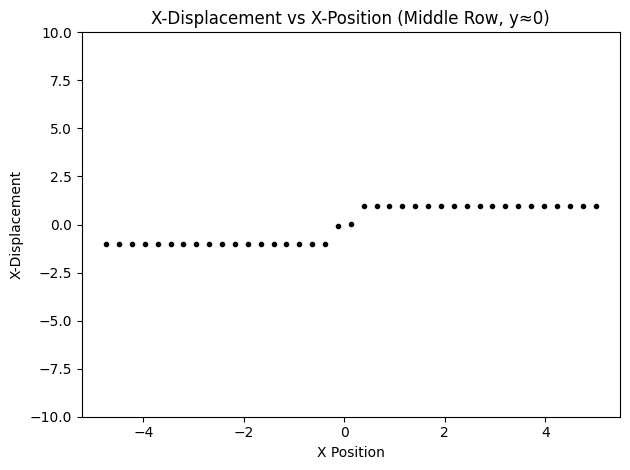

In [26]:
x_disp_to_plot = disp[41:80,0]
nodes_to_plot = params.pd_nodes[41:80,0]
#print(nodes_to_plot)

# Create the plot
fig, ax = plt.subplots()
ax.plot(nodes_to_plot, x_disp_to_plot, 'k.')  # Scatter plot like your 1D example
ax.set_xlabel("X Position")
ax.set_ylabel("X-Displacement")
ax.set_title("X-Displacement vs X-Position (Middle Row, y≈0)")
ax.set_ylim(-10, 10)  # Uncomment and adjust if you want fixed y-limits
plt.tight_layout()
plt.show()

In [9]:
print(results[10][-1])
print(results.damage[-1])

[0.         0.         0.         0.         0.         0.3794768
 0.19389248 0.14541948 0.04847312 0.09694642 0.14541942 0.14541936
 0.09694624 0.         0.         0.04847294 0.15187186 0.30631042
 0.9999963  0.9143605  0.9515232  0.9999963  0.35478354 0.20034498
 0.04847312 0.         0.         0.1454193  0.1454193  0.14541948
 0.14541948 0.04847312 0.14541948 0.1938926  0.3794769  0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.14030784 0.03664726 0.07329452
 0.03036612 0.         0.         0.         0.         0.
 0.         0.03036612 0.145186   0.33524114 0.50427437 0.93525475
 0.8986075  0.5042744  0.33524114 0.14518613 0.03036612 0.
 0.         0.         0.         0.         0.         0.03036612
 0.07329452 0.03664726 0.14030778 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.02518851 0.03039

ValueError: x and y must have same first dimension, but have shapes (22,) and (6,)

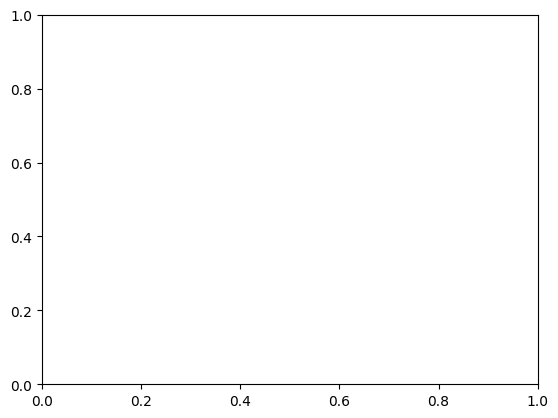

In [32]:
# Parameters for time calculation
#time_step = 7.5E-10  # From your code
max_time = 1.0E-02  # From your code
time_step = 5.0E-07
num_steps = int(max_time / time_step)

# Compute saved step indices (matching your mask logic)
step_inds = jnp.arange(num_steps)
mask_all = jnp.logical_or(
    jnp.logical_and(step_inds <= 6000, step_inds % 500 == 0),
    jnp.logical_and(
        step_inds >= 6000,
        jnp.logical_and(step_inds <= 15000, step_inds % 1000 == 0)
    )
)
saved_step_inds = step_inds[mask_all]

# Compute time for each saved step
saved_times = saved_step_inds * time_step

'''
# Option 1: Plot displacement vs. time for a specific node (e.g., center node)
# Assuming num_nodes is even for simplicity; adjust index as needed
center_node_idx = params.num_nodes // 2  # Middle node
displacements_center = results.disp_array[:, center_node_idx]  # Shape: (num_saved_steps,)

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(saved_times, displacements_center, label=f'Displacement of Node {center_node_idx}')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Displacement vs. Time (Center Node)')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Enable scientific notation on x-axis
'''

# Option 2: Plot damage accumulation (total damage over all nodes)
total_damage = jnp.sum(results.damage, axis=1)  # Sum damage across nodes at each saved step

#plt.subplot(1, 2, 2)
plt.plot(saved_times, total_damage, label='Total Damage', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Total Damage')
plt.title('Damage Accumulation vs. Time')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Enable scientific notation on x-axis

plt.tight_layout()
plt.show()

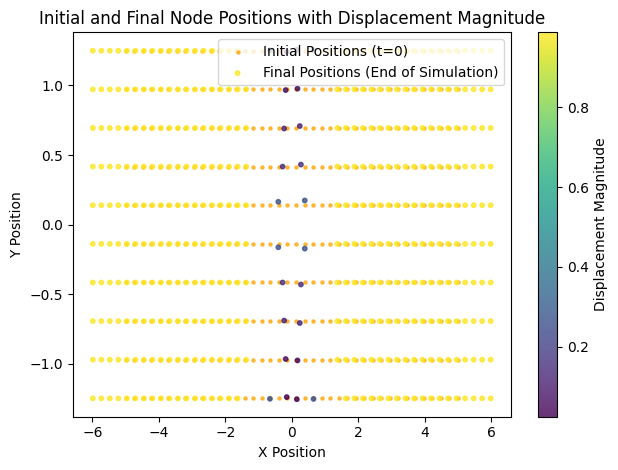

In [10]:
# Assuming results = _solve(...) has been run
disp_x = results[0]  # Shape: (num_nodes,) - x-displacements
disp_y = results[1]  # Shape: (num_nodes,) - y-displacements
positions = params.pd_nodes  # Shape: (num_nodes, 2) - node positions

# Stack into full displacement vectors
disp = jnp.stack([disp_x, disp_y], axis=-1)  # Shape: (num_nodes, 2)
#jax.debug.print("disp shape: {d}", d=disp.shape)

# Compute displacement magnitude (scalar for each node)
disp_magnitude = jnp.linalg.norm(disp, axis=1)  # Shape: (num_nodes,)

# Extract initial x/y positions for plotting
pos_x_init = positions[:, 0]
pos_y_init = positions[:, 1]

# Compute final (deformed) x/y positions
pos_x_final = positions[:, 0] + disp[:, 0]
pos_y_final = positions[:, 1] + disp[:, 1]

# Create the plot
fig, ax = plt.subplots()

# Plot initial positions as small black dots (time zero)
ax.scatter(pos_x_init, pos_y_init, c='orange', s=5, alpha=0.7, label='Initial Positions (t=0)')

# Plot final positions with displacement magnitude coloring
scatter = ax.scatter(pos_x_final, pos_y_final, c=disp_magnitude, cmap='viridis', s=10, alpha=0.8, label='Final Positions (End of Simulation)')

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_title("Initial and Final Node Positions with Displacement Magnitude")
ax.legend()  # Add legend to distinguish initial and final
plt.colorbar(scatter, label='Displacement Magnitude')  # Colorbar for final positions
plt.tight_layout()
plt.show()

### code calculating the area over which the initial damage is applied in a way that can be easily scaled.

In [ ]:
	#### Determine damage indices based on distance to center within bottom height_fraction ####
	damage_fraction_per_side=0.05
	height_fraction=0.7
 
	# Compute num_to_select_per_side using JAX operations (no int() or len())
	num_to_select_per_side = jnp.round(damage_fraction_per_side * num_nodes).astype(jnp.int32)
    
    # Compute y-range for bottom 'height_fraction'
	y_coords = pd_nodes[:, 1]
	y_min = jnp.min(y_coords)
	y_max = jnp.max(y_coords)
	y_threshold = y_min + height_fraction * (y_max - y_min)
    
    # Mask for nodes within the bottom height_fraction
	height_mask = (y_coords >= y_min) & (y_coords <= y_threshold)
    
    # Separate left and right nodes within the height mask
	left_mask = (pd_nodes[:, 0] < 0) & height_mask
	right_mask = (pd_nodes[:, 0] > 0) & height_mask
    
	left_nodes = jnp.where(left_mask)[0]  # Indices of left nodes in range
	right_nodes = jnp.where(right_mask)[0]  # Indices of right nodes in range
    
    # For left side: sort by distance to center (x=0), select closest
	if left_nodes.shape[0] > 0:  # Use shape[0] instead of len()
		left_x = pd_nodes[left_nodes, 0]
		left_distances = jnp.abs(left_x)  # Distance to x=0
		left_sorted_indices = jnp.argsort(left_distances)  # Sort by increasing distance
        # Use jnp.minimum instead of min
		num_select_left = jnp.minimum(num_to_select_per_side, left_nodes.shape[0])
		left_selected = left_nodes[left_sorted_indices[:num_select_left]]
	else:
		left_selected = jnp.array([], dtype=jnp.int32)
    
    # For right side: same as left
	if right_nodes.shape[0] > 0:
		right_x = pd_nodes[right_nodes, 0]
		right_distances = jnp.abs(right_x)
		right_sorted_indices = jnp.argsort(right_distances)
		num_select_right = jnp.minimum(num_to_select_per_side, right_nodes.shape[0])
		right_selected = right_nodes[right_sorted_indices[:num_select_right]]
	else:
		right_selected = jnp.array([], dtype=jnp.int32)
    
    # Combine and return as JAX array
	node_indices = jnp.concatenate([left_selected, right_selected])


10.424575
[0.25       0.25       0.25       0.25       0.25       0.25
 0.25       0.25       0.25       0.20715171 0.19166672 0.15311098
 0.07612842 0.04651701 0.25       0.25       0.25       0.25
 0.25       0.25       0.25       0.25       0.25       0.25
 0.25       0.25       0.25       0.25       0.25       0.25
 0.25       0.25       0.25       0.25       0.25       0.25
 0.25       0.25       0.25       0.25       0.25       0.25
 0.25       0.25      ]


In [7]:
print(results[7][0].sum())
print(results[7][-1].sum())

0.0
0.0


In [95]:
# Assuming results = _solve(...) has been run
disp = results[0]  # Shape: (num_nodes, 2) - displacement vectors
positions = params.pd_nodes  # Shape: (num_nodes, 2) - node positions

# Compute displacement magnitude (scalar for each node, like 1D displacement)
disp_magnitude = jnp.linalg.norm(disp, axis=1)  # Shape: (num_nodes,)

# Extract initial x/y positions for plotting
pos_x_init = positions[:, 0]
pos_y_init = positions[:, 1]

# Compute final (deformed) x/y positions
pos_x_final = positions[:, 0] + disp[:, 0]
pos_y_final = positions[:, 1] + disp[:, 1]

# Create mask for middle section in x-direction (e.g., x from -2.0 to 2.0, all y)
mask = (positions[:, 0] >= -2.0) & (positions[:, 0] <= 2.0)

# Apply mask to filter positions and displacements
pos_x_init_filtered = pos_x_init[mask]
pos_y_init_filtered = pos_y_init[mask]
pos_x_final_filtered = pos_x_final[mask]
pos_y_final_filtered = pos_y_final[mask]
disp_magnitude_filtered = disp_magnitude[mask]

# Create the plot
fig, ax = plt.subplots()

# Plot initial positions as small black dots (time zero), filtered
ax.scatter(pos_x_init_filtered, pos_y_init_filtered, c='black', s=5, alpha=0.7, label='Initial Positions (t=0)')

# Plot final positions with displacement magnitude coloring, filtered
scatter = ax.scatter(pos_x_final_filtered, pos_y_final_filtered, c=disp_magnitude_filtered, cmap='viridis', s=10, alpha=0.8, label='Final Positions (End of Simulation)')

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_title("Initial and Final Node Positions with Displacement Magnitude (X: -2 to 2)")
ax.legend()  # Add legend to distinguish initial and final
plt.colorbar(scatter, label='Displacement Magnitude')  # Colorbar for final positions
plt.tight_layout()
plt.show()

ValueError: axis 1 is out of bounds for array of dimension 1

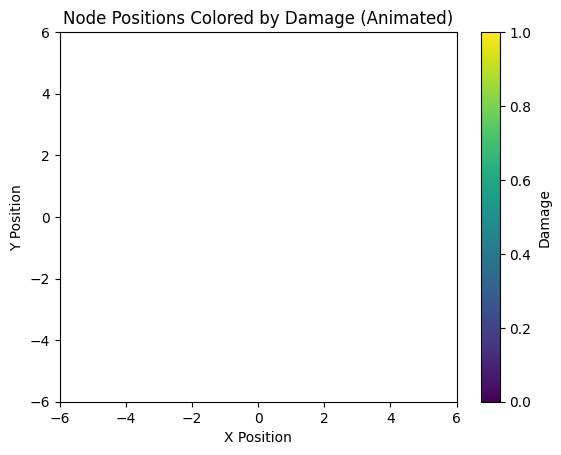

MovieWriter imagemagick unavailable; using Pillow instead.


In [36]:
forces_to_apply = results[11]  # Correct index for forces_array
damages = results[10]          # Correct index for damage
displacements = results[12]    # Correct index for disp_array (x-only)

fig, ax = plt.subplots()
sc = ax.scatter([], [], c=[], cmap="viridis", vmin=0, vmax=1, s=40)

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_title("Node Positions Colored by Damage (Animated)")

# Set axis limits based on node positions
#ax.set_xlim(params.pd_nodes[:, 0].min() - 0.5, params.pd_nodes[:, 0].max() + 0.5)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

# Add colorbar for damage
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Damage")

def init():
    sc.set_offsets(np.empty((0, 2)))  # Empty 2D coords
    sc.set_array(np.array([]))  # Empty colors
    return sc,

def update(frame):
    disp_x = displacements[frame]  # Shape: (num_nodes,) — x-displacements only
    dmg = damages[frame]          # Shape: (num_nodes,)
    
    # Deformed positions: add x-displacement, assume y=0 for simplicity
    deformed_positions = jnp.stack([params.pd_nodes[:, 0] + disp_x, params.pd_nodes[:, 1]], axis=1)  # Shape: (num_nodes, 2)
    
    sc.set_offsets(deformed_positions)  # Set deformed node positions (x, y)
    sc.set_array(dmg)                  # Color by damage
    #ax.set_aspect('equal', adjustable='box')
    ax.set_title(f"Deformed Positions, Force={forces_to_apply[frame]:.5e}")
    return sc,

ani = animation.FuncAnimation(fig, update, frames=len(displacements), init_func=init, blit=False, repeat=False)

plt.show()
ani.save("displacements_2d_strainEnergyDensity.gif", writer="imagemagick", fps=1)

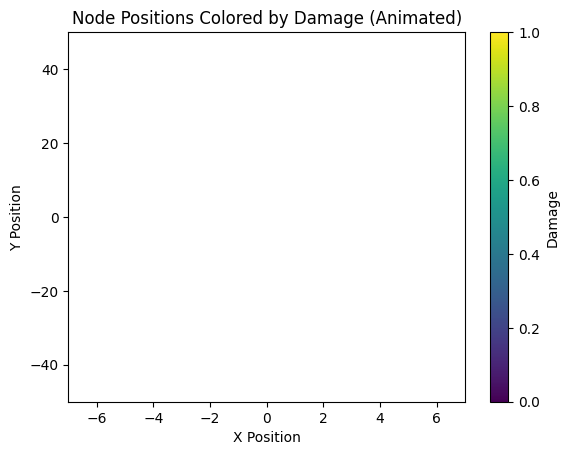

MovieWriter imagemagick unavailable; using Pillow instead.


In [134]:
forces_to_apply = results[11]  # Correct index for forces_array
damages = results[10]          # Correct index for damage
displacements_x = results[12]  # Correct index for disp_array (x-only)
displacements_y = results[13]  # Assuming we add disp_y_array to _solve and return it as results[13]; see notes below

fig, ax = plt.subplots()
sc = ax.scatter([], [], c=[], cmap="viridis", vmin=0, vmax=1, s=40)

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_title("Node Positions Colored by Damage (Animated)")

# Set axis limits based on node positions
#ax.set_xlim(params.pd_nodes[:, 0].min() - 0.5, params.pd_nodes[:, 0].max() + 0.5)
ax.set_xlim(-7, 7)
ax.set_ylim(-50, 50)

# Add colorbar for damage
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Damage")

def init():
    sc.set_offsets(np.empty((0, 2)))  # Empty 2D coords
    sc.set_array(np.array([]))  # Empty colors
    return sc,

def update(frame):
    disp_x = displacements_x[frame]  # Shape: (num_nodes,) — x-displacements
    disp_y = displacements_y[frame]  # Shape: (num_nodes,) — y-displacements
    dmg = damages[frame]             # Shape: (num_nodes,)
    
    # Deformed positions: add BOTH x and y displacements for full 2D deformation
    deformed_positions = jnp.stack([params.pd_nodes[:, 0] + disp_x, params.pd_nodes[:, 1] + disp_y], axis=1)  # Shape: (num_nodes, 2)
    
    sc.set_offsets(deformed_positions)  # Set deformed node positions (x, y)
    sc.set_array(dmg)                  # Color by damage
    
    ax.set_title(f"Deformed Positions, Y dir disp, Force={forces_to_apply[frame]:.3e}")
    return sc,

ani = animation.FuncAnimation(fig, update, frames=len(displacements_x), init_func=init, blit=False, repeat=False)

plt.show()
ani.save("displacements_2d.gif", writer="imagemagick", fps=2)

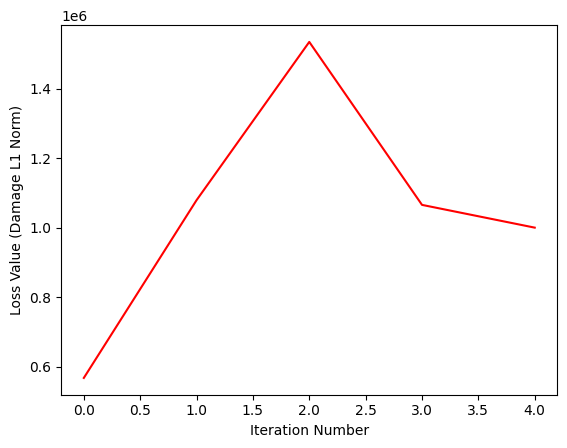

In [10]:
loss_to_plot_200it = jnp.array(loss_to_plot)

index_array__opt_thick_5 = np.arange(len(loss_to_plot_200it))

plt.plot(index_array__opt_thick_5, loss_to_plot_200it, c='red', label='init thick 5')
#plt.plot(index_array__opt_thick_5,loss_to_plot_100it,c='blue',label='init thick 5')

#plt.title("Loss vs Iteration Number")
plt.xlabel('Iteration Number')
plt.ylabel('Loss Value (Damage L1 Norm)')
#plt.legend()

#plt.savefig("strainEnergy_variedLossFunction.png", dpi=300, bbox_inches="tight")
plt.show()

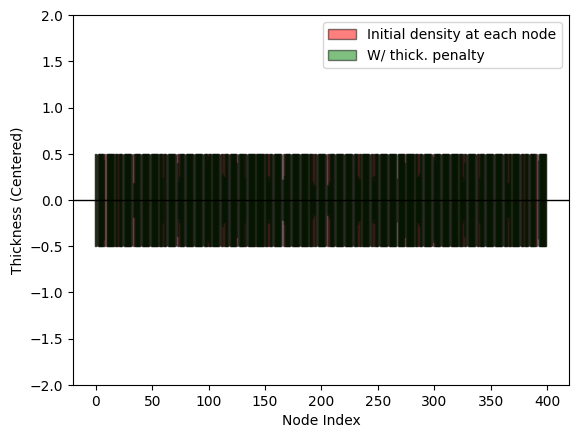

In [ ]:
init_density = jnp.full((params.num_nodes,), density_field)/2.0
x = np.arange(len(init_density))

#plt.clf()
plt.bar(x, init_density, bottom=-init_density/2,
         color="red", edgecolor="k", alpha=0.5, label="Initial density at each node")
plt.bar(x, full_density_field, bottom=-full_density_field/2,
         color="green", edgecolor="k", alpha=0.5, label="W/ thick. penalty")



plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Node Index")
plt.ylabel("Thickness (Centered)")
#plt.title("Initial vs Optimized Thickness Per Node")
plt.legend()
plt.ylim(-2, 2)  # fixed axis range

#plt.savefig("overlayed_thickness.png", dpi=300, bbox_inches="tight")
plt.show()

### plotting optimized density in a grid like structure

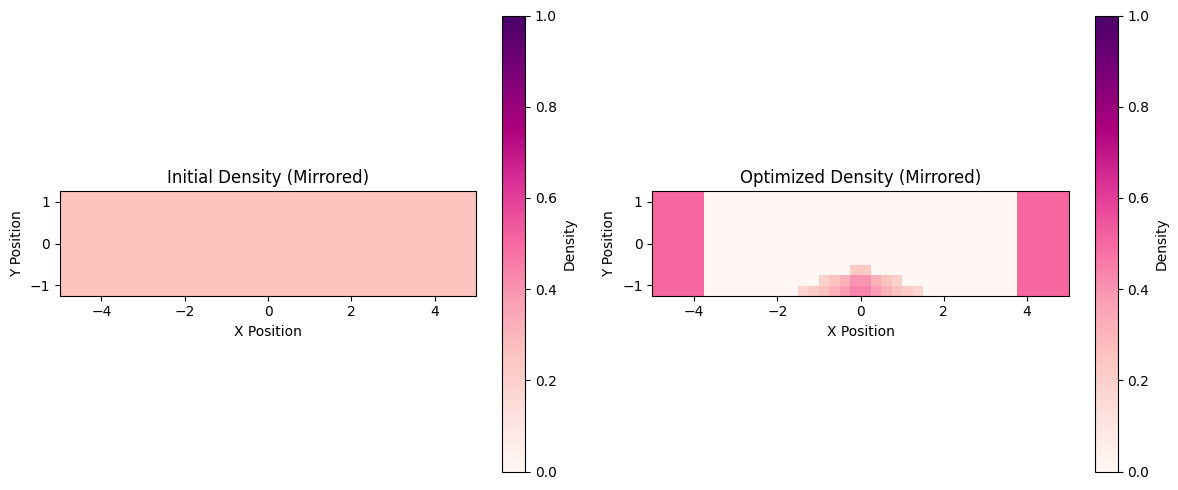

In [9]:
# Assuming params has nx and ny defined (nx = number_of_elements, ny = number_of_elements // 4)
nx = params.number_of_elements
ny = params.number_of_elements // 4

# Reshape density fields to grid shape (ny, nx)
init_density_grid = init_density.reshape((ny, nx))
full_density_field_grid = full_density_field.reshape((ny, nx))

# Create mirrored versions for plotting (mirror left half to right half)
left_half_init = init_density_grid[:, :nx//2]
mirrored_init_grid = jnp.concatenate([left_half_init, jnp.flip(left_half_init, axis=1)], axis=1)

left_half_full = full_density_field_grid[:, :nx//2]
mirrored_full_grid = jnp.concatenate([left_half_full, jnp.flip(left_half_full, axis=1)], axis=1)

# Define the extent for the plot (full grid)
x = jnp.linspace(-params.bar_length/2, params.bar_length/2, nx)
y = jnp.linspace(-params.bar_length/8, params.bar_length/8, ny)
extent = [x[0], x[-1], y[0], y[-1]]

# Create subplots for initial and optimized density
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot initial density (mirrored grid)
im1 = axes[0].imshow(mirrored_init_grid, cmap='RdPu', extent=extent, origin='lower', vmin=0, vmax=1)
axes[0].set_title("Initial Density (Mirrored)")
axes[0].set_xlabel("X Position")
axes[0].set_ylabel("Y Position")
plt.colorbar(im1, ax=axes[0], label='Density')

# Plot optimized density (mirrored grid)
im2 = axes[1].imshow(mirrored_full_grid, cmap='RdPu', extent=extent, origin='lower', vmin=0, vmax=1)
axes[1].set_title("Optimized Density (Mirrored)")
axes[1].set_xlabel("X Position")
axes[1].set_ylabel("Y Position")
plt.colorbar(im2, ax=axes[1], label='Density')

plt.tight_layout()
plt.show()

## Optimization Code

In [ ]:
##################################################
# # Now using Optax to maximize
# scalar param
#param = jnp.array([1.0])
density_field = 0.50
thickness = jnp.full((params.num_nodes,), thickness0)
param = jnp.full((params.num_nodes,), density_field)
init_density = param.copy()

# setting density values in no_damage_regions
left_fixed_density = 0.50
right_fixed_density = 0.50

# optimizing only half of bar, such that thickness is symmetric
num_nodes = params.num_nodes
mid_index = num_nodes // 2  # midpoint of bar

no_damage_region_left = params.no_damage_region_left
no_damage_region_right = params.no_damage_region_right

# Get unique x-values (already sorted)
unique_x = jnp.unique(params.pd_nodes[:, 0])

# Define excluded x-values (leftmost and rightmost)
leftmost_x = unique_x[:5]   # First 5 x-values (left no-damage)
rightmost_x = unique_x[-5:] # Last 5 x-values (right no-damage)
excluded_x = jnp.concatenate([leftmost_x, rightmost_x])

# Define middle_region as nodes NOT in excluded x-values
middle_mask = ~jnp.isin(params.pd_nodes[:, 0], excluded_x)
middle_region = jnp.where(middle_mask)[0]

#print("middle_region: ", middle_region)
#print("middle_region size: ", middle_region.size)  # Should be ~300 for your gri

# Sort middle_region by x-position for symmetry
middle_region = middle_region[jnp.argsort(params.pd_nodes[middle_region, 0])]

# Define optimizable_indices as the left half of middle_region
mid_middle = len(middle_region) // 2
optimizable_indices = middle_region[:mid_middle]

# Initialize param with the correct size
param = jnp.ones((mid_middle,)) * density_field

loss_to_plot = []
damage_to_plot = []
strain_energy_to_plot = []

learning_rate = 0.1
#num_steps = 70
num_steps = 20
density_min = 0.0
density_max = 1.0

# Define gradient bounds
lower = 1E-2
upper = 20

max_time = 1.0E-02

# Optax optimizer
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(param)

# Optimization loop
damage_threshold = 0.5

# Loss function (already defined as 'loss')
loss_and_grad = jax.value_and_grad(loss, argnums=3)

# Clamp function
def clamp_params(grads):
	lower = 1E-05
	upper = 1.0E10
	#jax.debug.print("entering clamp_params: {t}", t=grads)
	grads = jax.tree_util.tree_map(lambda x: jnp.clip(jnp.abs(x), lower, upper), grads)
	#jax.debug.print("grad after clamping: {t}", t=grads)
	return grads
def make_symmetric_density(left_params, left_fixed_density, right_fixed_density):
    """Return full symmetric density array of shape (num_nodes,)."""

    # Mirror optimized section (no reversal for symmetry)
    mirrored = left_params  # Exact copy, not reversed
    middle_full = jnp.concatenate([left_params, mirrored])

    # Construct full bar density field
    full_density_field = jnp.ones((num_nodes,)) * density_field  # shape (num_nodes,)

    # Insert middle region
    full_density_field = full_density_field.at[middle_region].set(middle_full)

    # Fix the outer ends
    full_density_field = full_density_field.at[no_damage_region_left].set(left_fixed_density)
    full_density_field = full_density_field.at[no_damage_region_right].set(right_fixed_density)

    return full_density_field

# Optimization loop
for step in range(num_steps):
	def true_fn(thickness):
		jax.debug.print("thickness is all finite.")
		return thickness

	def false_fn(thickness):
		jax.debug.print("Non-finite thickness detected: {t}", t=thickness)
		return thickness

	full_density_field = make_symmetric_density(param, left_fixed_density, right_fixed_density)
	assert jnp.all(jnp.isfinite(param)), "Initial density contains NaNs!"


	# enforce fixed region if needed
	full_density_field = full_density_field.at[no_damage_region_left].set(left_fixed_density)
	full_density_field = full_density_field.at[no_damage_region_right].set(right_fixed_density)

	# Compute loss and gradients (grads wrt half param)
	loss_val, grads_full = loss_and_grad(
        params, state, thickness, full_density_field, 
        forces_array, allow_damage, max_time)

	# Extract grads only for half region
	grads = grads_full[optimizable_indices]

	updates, opt_state = optimizer.update(grads, opt_state, param)
	param = optax.apply_updates(param, updates)
 
	# Enforcing density bounds of 0-1
	param = jnp.clip(param, 0.0, 1.0)
 
    # Now compute strain_energy and damage separately for plotting
	output_vals = _solve(params, state, thickness, full_density_field, forces_array, allow_damage, max_time)

	loss_to_plot.append(loss_val)
	strain_energy_to_plot.append(output_vals.strain_energy)
 
	# Compute final damage for plotting
	final_damage = compute_damage(output_vals.vol_state, output_vals.influence_state, output_vals.undamaged_influence_state)
	damage_to_plot.append(final_damage)

   # Check if all damage is below 0.5 and exit early if so
	if jnp.all(final_damage < 0.5):
		print(f"Early exit at step {step}: All damage values are below 0.5")
		break
 
	#print(f"Step {step}, loss={loss_val}, density_field.sum={full_density_field.sum()}")
	print(f"Step {step}, loss={loss_val}, density_field.sum={full_density_field.sum()}, gradient {grads}")
	#print("total damage in optimization loop: ", output_vals.damage.sum())
	#print("damage in optimization loop: ", damage[-1])



strain_energy_norm in loss: 431780.96875
loss_value in loss: 431780.96875
Step 0, loss=431780.96875, density_field.sum=200.0, gradient [-25.914352  -35.766594  -39.36483   -40.753048  -40.15719   -37.98444
 -34.66179   -30.663628  -26.383358  -18.86776   -24.493208  -34.349056
 -38.728134  -40.699608  -40.298256  -38.000603  -34.30547   -29.762001
 -24.973446  -17.590534  -25.1297    -35.01622   -39.358868  -41.319435
 -40.754417  -38.08746   -33.93316   -29.080116  -24.33405   -17.281239
 -25.127438  -34.979652  -39.453346  -41.53981   -40.932888  -37.971863
 -33.396523  -28.218906  -23.388018  -16.633839  -25.423962  -35.462654
 -39.998264  -42.059414  -41.283188  -38.02423   -33.12287   -27.750015
 -22.897205  -16.253061  -25.915007  -35.9645    -40.428894  -42.33351
 -41.300987  -37.67656   -32.428944  -26.866348  -22.066944  -15.762592
 -26.28096   -36.558712  -41.038258  -42.851196  -41.57312   -37.59348
 -31.964851  -26.183678  -21.357025  -15.188657  -26.755943  -37.252274
 -41